# Multi Linear regression


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

In [69]:
df = pd.read_csv("economic_index.csv")

df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [70]:
df.drop(columns=["Unnamed: 0",'year','month'],inplace =True)

df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


<Figure size 1500x1500 with 0 Axes>

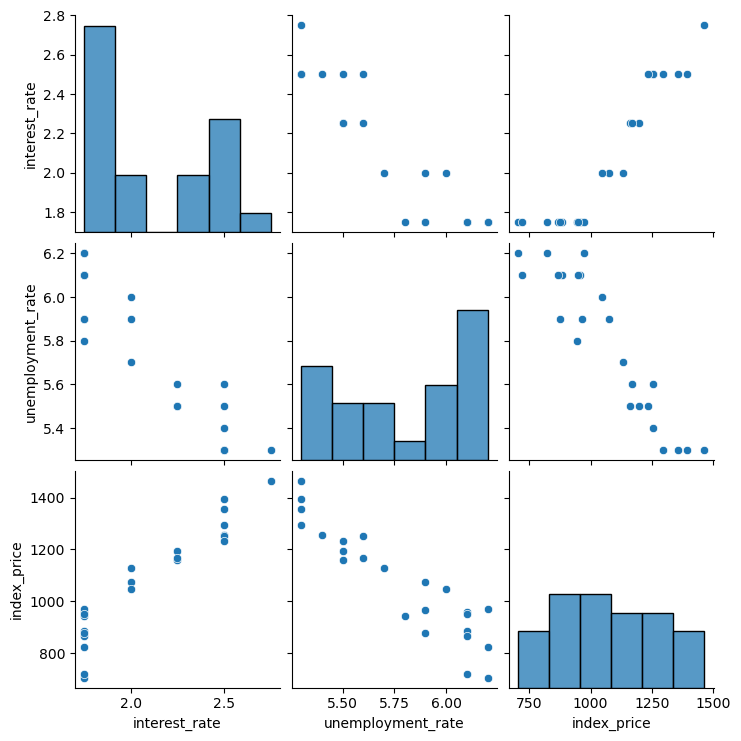

In [71]:
plt.figure(figsize=(15,15))

sns.pairplot(df)

In [72]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

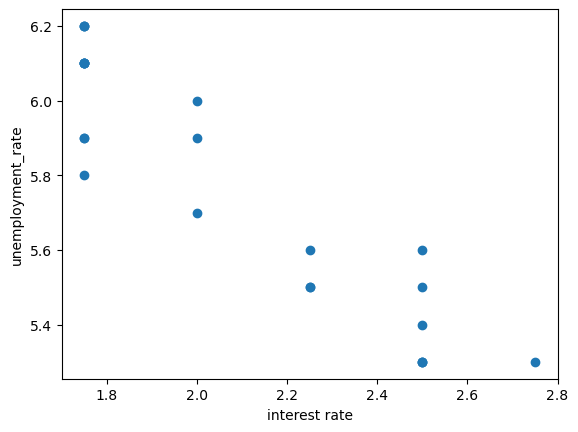

In [73]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])

plt.xlabel("interest rate")
plt.ylabel('unemployment_rate')

In [74]:
# independent features

X = df.iloc[:,:-1] #from data only not include the last coloumn
y=  df.iloc[:,-1] # frpom dataset only include the last coloumn

In [75]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state= 42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

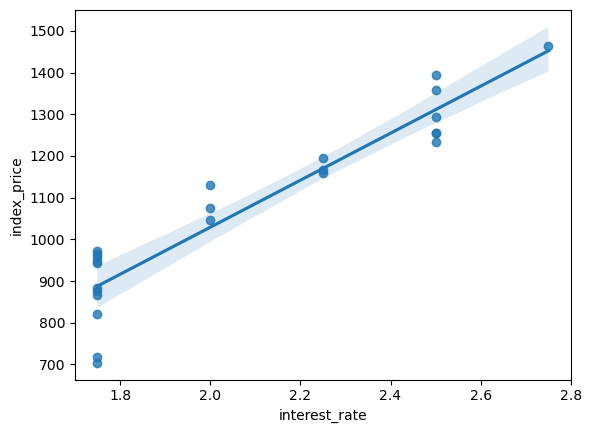

In [77]:
sns.regplot(x =df['interest_rate'], y =df['index_price'])

# TypeError: regplot() takes from 0 to 1 positional arguments but 2 were given

# That error is happening because the API for sns.regplot() has changed — it no longer accepts positional arguments for x and y.

# ✅ Fix

# You need to pass them as keyword arguments:

# import seaborn as sns

# sns.regplot(x=df['interest_rate'], y=df['index_price'])
# 💡 Why this happens

# In newer versions of Seaborn, many plotting functions enforce keyword-only arguments for clarity and to avoid ambiguity.

# 🔁 Alternative (cleaner style)

# You can also pass column names with data=:

# sns.regplot(x='interest_rate', y='index_price', data=df)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

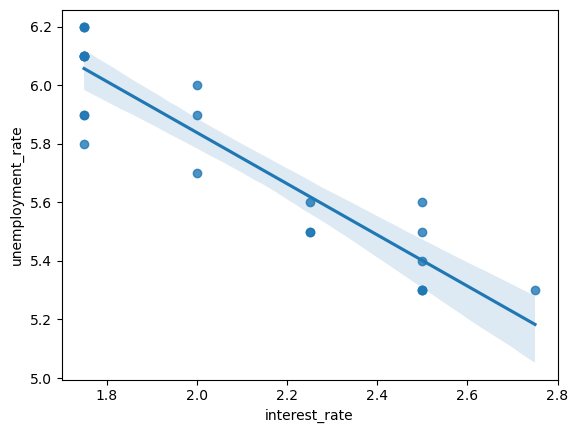

In [78]:
sns.regplot(x =df['interest_rate'], y =df['unemployment_rate'])


<Axes: xlabel='index_price', ylabel='unemployment_rate'>

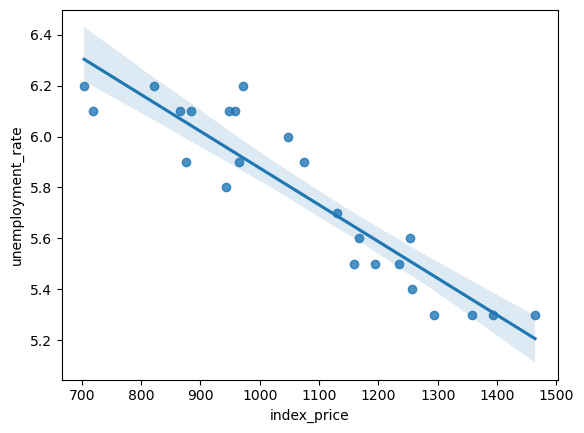

In [79]:
sns.regplot(x =df['index_price'], y =df['unemployment_rate'])


In [80]:
X_train

,interest_rate,unemployment_rate
13,1.75,5.9
1,2.50,5.3
21,1.75,6.2
5,2.50,5.6
2,2.50,5.3
12,2.00,6.0
15,1.75,6.1
3,2.50,5.3
4,2.50,5.4
22,1.75,6.2


In [81]:
X_test.shape

(6, 2)

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [83]:
X_test = scaler.fit_transform(X_test)


In [84]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [85]:
reg.fit(X_train, y_train)



LinearRegression()

In [90]:
from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(reg, X_train,y_train, scoring= 'neg_mean_squared_error',cv =3) 
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [91]:
np.mean(validation_score)

np.float64(-5914.828180162396)

In [92]:
# prediction

y_pred =reg.predict(X_test)

In [93]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [94]:
len(df)

24

In [96]:
from sklearn.metrics import r2_score

score = r2_score(y_test,y_pred)
print(score)



0.7591371539010254


In [99]:

#adjusted r2
print(1 - (1-score)*(len(y_test)-1)/(len(y_test) - X_test.shape[1] - 1))

0.5985619231683756


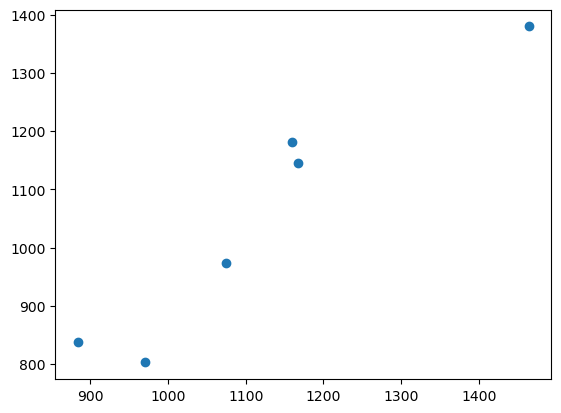

In [101]:
# assumptions

plt.scatter(y_test,y_pred) #-> there is good linear regression in y pred and y-test

In [103]:
residuals = y_test-y_pred # distance between the points
residuals

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64

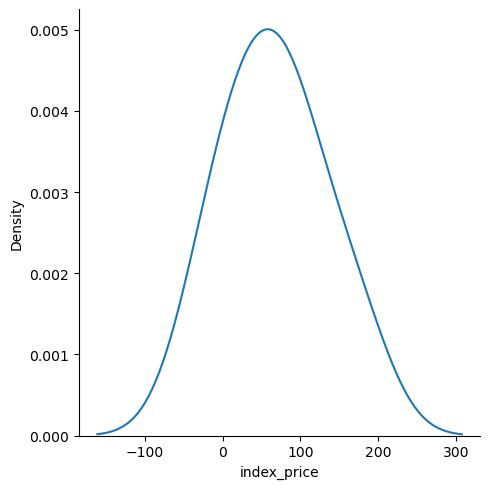

In [104]:
sns.displot(residuals,kind='kde') # if a normal distribution is plotted then the model is working well

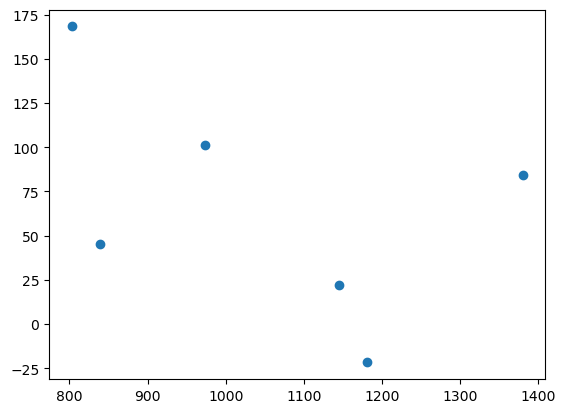

In [106]:
# scatter plot of y_pred vs residuals

plt.scatter(y_pred,residuals) #if the points are uniformly distributed than its mean model working well

In [108]:
import statsmodels.api as sm

model = sm.OLS(y_train,X_train).fit()

In [110]:
model.summary()

d:\Anaconda\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 08 Apr 2026   Prob (F-statistic):                       0.754
Time:                        11:58:03   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [111]:
print("regression coeff: ",reg.coef_)

regression coeff:  [  88.27275507 -116.25716066]


In [117]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)

print(mse)
print(mae)

print("rmse: ",np.sqrt(mse))

8108.567426306611
73.80444932337099
rmse:  90.04758423359624
